# <u>Muhammad Owais Ur Rehaman Assignment</u>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## Creating a dataset

In [4]:
# Creating dataset of 500 employees with the following attributes
data={
    'ID':np.random.randint(1,500,size=500),
    'Name':np.random.choice(['John','Jane','Mike','Sarah','David','Ali','Ahmed','Abbas','Alam'],size=500),
    'Age':np.random.randint(22,60,size=500),
    'Gender':np.random.choice(['Male','Female'],size=500),
    'Salary':np.random.randint(4000,12000,size=500),
    'year_at_company':np.random.randint(1,30,size=500),
    'performance':np.random.randint(1,5,size=500)
}

In [5]:
df=pd.DataFrame(data)
df.head()

,ID,Name,Age,Gender,Salary,year_at_company,performance
0,135,Sarah,34,Female,7343,5,3
1,249,Mike,35,Male,8752,24,1
2,121,John,29,Female,5754,26,1
3,482,Abbas,46,Male,8289,1,4
4,117,Ali,50,Male,9175,20,3


In [6]:
df['promotion_eligibility']=np.where(df['performance']>3,'Yes','No')
df.head()

,ID,Name,Age,Gender,Salary,year_at_company,performance,promotion_eligibility
0,135,Sarah,34,Female,7343,5,3,No
1,249,Mike,35,Male,8752,24,1,No
2,121,John,29,Female,5754,26,1,No
3,482,Abbas,46,Male,8289,1,4,Yes
4,117,Ali,50,Male,9175,20,3,No


In [7]:
df.rename(columns={'year_at_company':'S_Duration','promotion_eligibility':'eligibility'},inplace=True)
df

,ID,Name,Age,Gender,Salary,S_Duration,performance,eligibility
0,135,Sarah,34,Female,7343,5,3,No
1,249,Mike,35,Male,8752,24,1,No
2,121,John,29,Female,5754,26,1,No
3,482,Abbas,46,Male,8289,1,4,Yes
4,117,Ali,50,Male,9175,20,3,No
...,...,...,...,...,...,...,...,...
495,311,Alam,34,Male,9939,23,4,Yes
496,129,David,30,Female,5762,28,1,No
497,498,Abbas,22,Male,10213,22,4,Yes
498,31,Sarah,41,Male,9105,22,3,No


#<span style="color:cyan"><u> Set 10% salary values to missing NaN </u></span>

In [8]:
np.random.seed(0)
get_nan=np.random.rand(len(df))<0.1
df.loc[get_nan,'Salary']=np.nan
df.head(10)

,ID,Name,Age,Gender,Salary,S_Duration,performance,eligibility
0,135,Sarah,34,Female,7343.0,5,3,No
1,249,Mike,35,Male,8752.0,24,1,No
2,121,John,29,Female,5754.0,26,1,No
3,482,Abbas,46,Male,8289.0,1,4,Yes
4,117,Ali,50,Male,9175.0,20,3,No
5,165,John,31,Female,6606.0,6,2,No
6,174,David,24,Female,7484.0,22,1,No
7,359,John,34,Female,8138.0,25,4,Yes
8,108,Ali,38,Male,6075.0,21,1,No
9,298,Jane,43,Male,8134.0,11,4,Yes


#<span style="color:orange"><u> To check which columns contains the NaN values </u></span>

In [9]:
df.isnull().sum()

ID              0
Name            0
Age             0
Gender          0
Salary         50
S_Duration      0
performance     0
eligibility     0
dtype: int64

#<span style="color:green"><u> Select only that column that have missing NaN </u></span>

In [10]:
columns_with_nan=df.columns[df.isna().any()].tolist()
columns_with_nan

['Salary']

In [11]:
ser=df.isna().any()
ser # This code tells us that is there any column with missing NaN


ID             False
Name           False
Age            False
Gender         False
Salary          True
S_Duration     False
performance    False
eligibility    False
dtype: bool

In [12]:
ser1=df.isna()
ser1.head() # This code tells us that is there any dataframe cell with missing NaN

,ID,Name,Age,Gender,Salary,S_Duration,performance,eligibility
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False


## Replace the performance 5% values with invalid (-1,6)

In [13]:
np.random.seed(0)
randno=int(len(df)*0.05)
replace_indexes=df['performance'].sample(n=randno).index
df.loc[replace_indexes,'performance']=np.random.choice([-1,6],size=randno)
df.head()

,ID,Name,Age,Gender,Salary,S_Duration,performance,eligibility
0,135,Sarah,34,Female,7343.0,5,3,No
1,249,Mike,35,Male,8752.0,24,1,No
2,121,John,29,Female,5754.0,26,1,No
3,482,Abbas,46,Male,8289.0,1,4,Yes
4,117,Ali,50,Male,9175.0,20,3,No


In [14]:
# np.random.seed(0)
# res=df['performance'].sample(n=10,random_state=0)
# res

In [15]:
# res1=df['performance'].sample(n=10,random_state=0).index
# res1

# Fill the salary with the Mean

In [16]:
mean_sal=df['Salary'].mean()
df['Salary'].fillna(mean_sal,inplace=True)
df.head(50)

C:\Users\pak\AppData\Local\Temp\ipykernel_18624\2311846960.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Salary'].fillna(mean_sal,inplace=True)


,ID,Name,Age,Gender,Salary,S_Duration,performance,eligibility
0,135,Sarah,34,Female,7343.000000,5,3,No
1,249,Mike,35,Male,8752.000000,24,1,No
2,121,John,29,Female,5754.000000,26,1,No
3,482,Abbas,46,Male,8289.000000,1,4,Yes
4,117,Ali,50,Male,9175.000000,20,3,No
5,165,John,31,Female,6606.000000,6,2,No
6,174,David,24,Female,7484.000000,22,1,No
7,359,John,34,Female,8138.000000,25,4,Yes
8,108,Ali,38,Male,6075.000000,21,1,No
9,298,Jane,43,Male,8134.000000,11,4,Yes


In [17]:
df['Salary']=df['Salary'].round(2)
df
# This code will restrict the salary to only one decimal number

,ID,Name,Age,Gender,Salary,S_Duration,performance,eligibility
0,135,Sarah,34,Female,7343.0,5,3,No
1,249,Mike,35,Male,8752.0,24,1,No
2,121,John,29,Female,5754.0,26,1,No
3,482,Abbas,46,Male,8289.0,1,4,Yes
4,117,Ali,50,Male,9175.0,20,3,No
...,...,...,...,...,...,...,...,...
495,311,Alam,34,Male,9939.0,23,4,Yes
496,129,David,30,Female,5762.0,28,1,No
497,498,Abbas,22,Male,10213.0,22,4,Yes
498,31,Sarah,41,Male,9105.0,22,3,No


## Filter out the Employee's with invalid scores

In [18]:
invalid_score_employee=df.loc[(df['performance']<0)|(df['performance']>5),('Name','ID','Gender')]
invalid_score_employee.head()

,Name,ID,Gender
15,John,256,Female
37,Ali,289,Male
45,Jane,207,Male
90,John,414,Male
108,Sarah,438,Male


In [19]:
invalid_score_employee['Gender']=invalid_score_employee['Gender'].replace({'Male':1,'Female':0})
invalid_score_employee.head(15)

C:\Users\pak\AppData\Local\Temp\ipykernel_18624\1458305922.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  invalid_score_employee['Gender']=invalid_score_employee['Gender'].replace({'Male':1,'Female':0})


,Name,ID,Gender
15,John,256,0
37,Ali,289,1
45,Jane,207,1
90,John,414,1
108,Sarah,438,1
153,Abbas,24,1
154,Abbas,2,0
159,John,172,0
171,Jane,336,1
205,David,37,1


## Department_Wise Salary analysis

In [20]:
df['Department']=np.random.choice(['Education','FIA','FBR','IB','Police','Judge','Medical','Senate','Ministry'
                                  ,'IT'],size=500)
df.head()

,ID,Name,Age,Gender,Salary,S_Duration,performance,eligibility,Department
0,135,Sarah,34,Female,7343.0,5,3,No,FIA
1,249,Mike,35,Male,8752.0,24,1,No,IB
2,121,John,29,Female,5754.0,26,1,No,FBR
3,482,Abbas,46,Male,8289.0,1,4,Yes,Police
4,117,Ali,50,Male,9175.0,20,3,No,IT


In [21]:
df.groupby('Department')['Salary'].mean()

Department
Education    7597.715833
FBR          7956.265098
FIA          7217.545882
IB           7714.218868
IT           8729.440870
Judge        7597.057333
Medical      8717.615000
Ministry     7749.773000
Police       8318.307500
Senate       8313.102979
Name: Salary, dtype: float64

## Find the total number of employees in each department

In [22]:
df.groupby('Department')['Name'].count()

Department
Education    48
FBR          51
FIA          51
IB           53
IT           46
Judge        60
Medical      56
Ministry     40
Police       48
Senate       47
Name: Name, dtype: int64

In [23]:
# Identifying the department with the highest average salary
highest_avg_sal_mean=df.groupby('Department')['Salary'].mean()
highest_avg_sal_dept=highest_avg_sal_mean.idxmax()
highest_avg_sal=highest_avg_sal_mean.max()
#highest_avg_sal.round(2)
print(f"The department {highest_avg_sal_dept} has getting the maximum average salary of by {highest_avg_sal.round(2)}")

The department IT has getting the maximum average salary of by 8729.44


## Average salary of employees who are eligible for promotion


In [24]:
# elig_employee=df[df['performance'].isin([4,5])]
elig_employee=df[df['eligibility'].isin(['Yes'])]
avg_elig_emp_sal=elig_employee['Salary'].mean()
print(f"The employees eligible for promotion getting the average salary of by {avg_elig_emp_sal.round(2)}")

The employees eligible for promotion getting the average salary of by 7884.87


In [25]:
inelig_employee=df[df['eligibility'].isin(['No'])]
inelig_employee

,ID,Name,Age,Gender,Salary,S_Duration,performance,eligibility,Department
0,135,Sarah,34,Female,7343.0,5,3,No,FIA
1,249,Mike,35,Male,8752.0,24,1,No,IB
2,121,John,29,Female,5754.0,26,1,No,FBR
4,117,Ali,50,Male,9175.0,20,3,No,IT
5,165,John,31,Female,6606.0,6,2,No,Senate
...,...,...,...,...,...,...,...,...,...
490,202,Jane,51,Female,4961.0,4,1,No,Medical
492,43,David,27,Female,8079.0,24,3,No,Judge
494,175,Alam,54,Male,10009.0,5,3,No,IB
496,129,David,30,Female,5762.0,28,1,No,Police


# <span style="color:red"><u>Box Plot Visualization</u></span>

In [26]:
df['eligibility'] = df['eligibility'].map({'Yes': True, 'No': False})
eligible = df[df['eligibility']]['Salary']
eligible=df[df['eligibility']]['Salary']
non_eligible=df[~df['eligibility']]['Salary']
non_eligible

0       7343.0
1       8752.0
2       5754.0
4       9175.0
5       6606.0
        ...   
490     4961.0
492     8079.0
494    10009.0
496     5762.0
498     9105.0
Name: Salary, Length: 396, dtype: float64

C:\Users\pak\AppData\Local\Temp\ipykernel_18624\3583625201.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([eligible, non_eligible], labels=['Eligible', 'Not Eligible'])


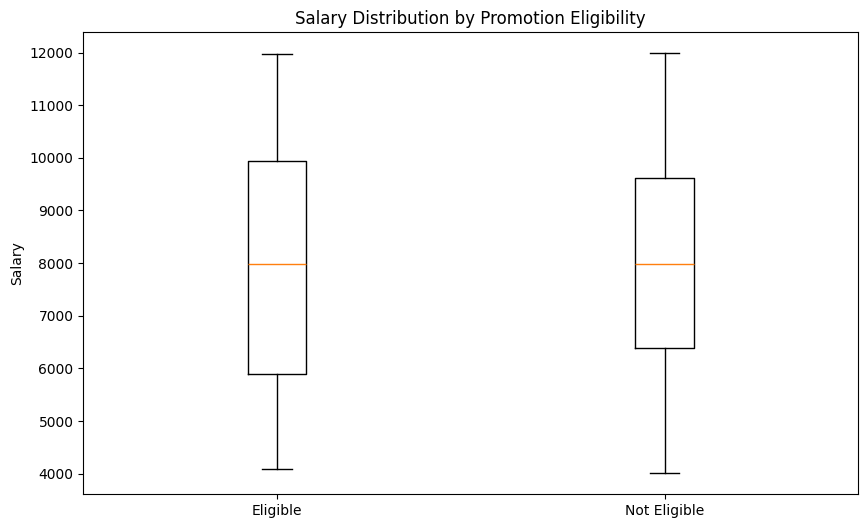

In [27]:
plt.figure(figsize=(10, 6))
plt.boxplot([eligible, non_eligible], labels=['Eligible', 'Not Eligible'])
plt.title('Salary Distribution by Promotion Eligibility')
plt.ylabel('Salary')
plt.show()

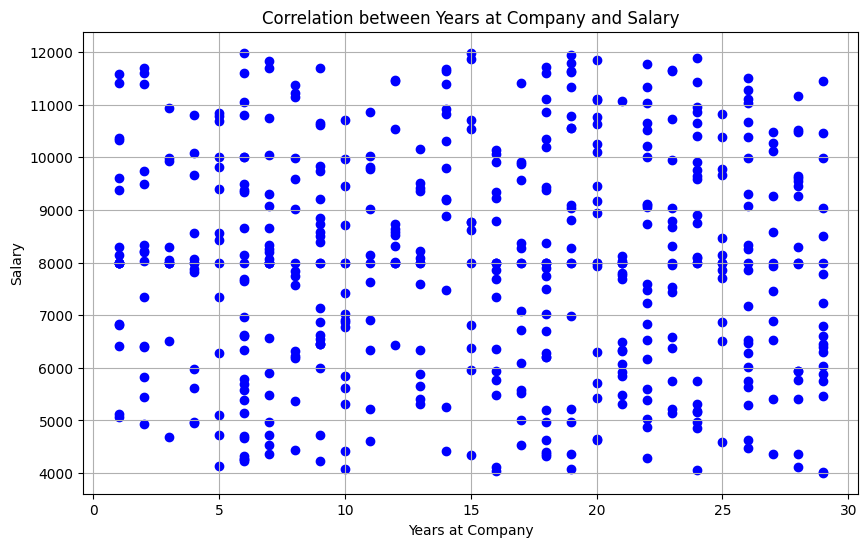

In [28]:
plt.figure(figsize=(10, 6))
plt.scatter(df['S_Duration'], df['Salary'], color='blue')
plt.title('Correlation between Years at Company and Salary')
plt.xlabel('Years at Company')
plt.ylabel('Salary')
plt.grid(True)
plt.show()

ValueError: num must be an integer with 1 <= num <= 4, not 5

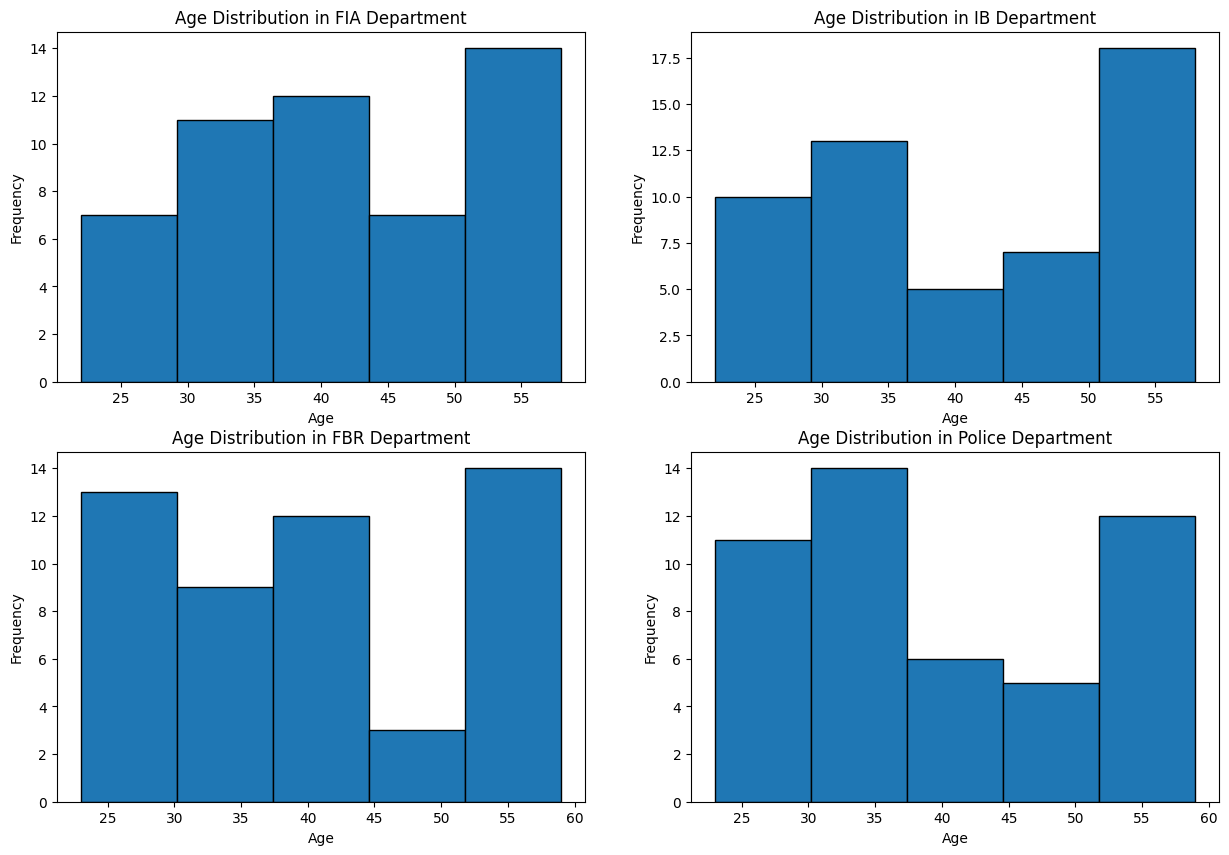

In [29]:
# Group by 'Department'
departments = df['Department'].unique()

# Create a histogram for each department
plt.figure(figsize=(15, 10))
for i, department in enumerate(departments, 1):
    plt.subplot(2, 2, i)
    df[df['Department'] == department]['Age'].plot(kind='hist', bins=5, edgecolor='black')
    plt.title(f'Age Distribution in {department} Department')
    plt.xlabel('Age')
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


# <span style="color:orange"><u>Group employees by Department and calculate</u></style>
> The average Salary ($) in each department.
> 
> The total number of employees in each department.

In [31]:
df.head()

,ID,Name,Age,Gender,Salary,S_Duration,performance,eligibility,Department
0,135,Sarah,34,Female,7343.0,5,3,False,FIA
1,249,Mike,35,Male,8752.0,24,1,False,IB
2,121,John,29,Female,5754.0,26,1,False,FBR
3,482,Abbas,46,Male,8289.0,1,4,True,Police
4,117,Ali,50,Male,9175.0,20,3,False,IT


In [37]:
grouped = df.groupby('Department').agg(
    average_salary=('Salary', 'mean'),
    total_employees=('Salary', 'size')
)
grouped['average_salary'].round(2).head()

Department
Education    7597.72
FBR          7956.27
FIA          7217.55
IB           7714.22
IT           8729.44
Name: average_salary, dtype: float64

### <u>Bar Chart: Create a bar chart to compare the average salaries across different
### departments. What does this chart reveal about salary distribution in the company?</u>

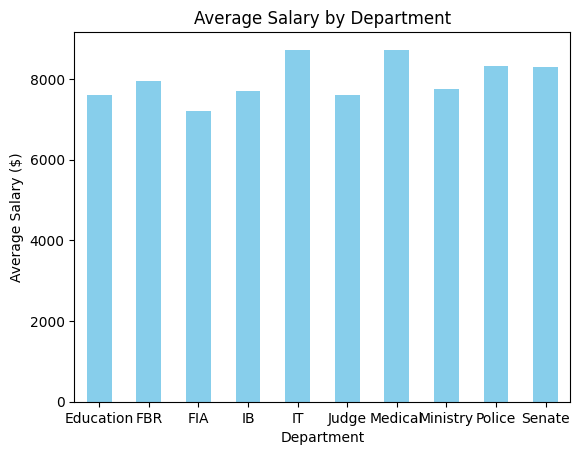

In [38]:
grouped['average_salary'].plot(kind='bar', color='skyblue')
plt.title('Average Salary by Department')
plt.xlabel('Department')
plt.ylabel('Average Salary ($)')
plt.xticks(rotation=0)
plt.show()

# Line Plot: 
### Use a line plot to visualize salary trends based on the number of years
### employees have been with the company. How does salary change with experience?

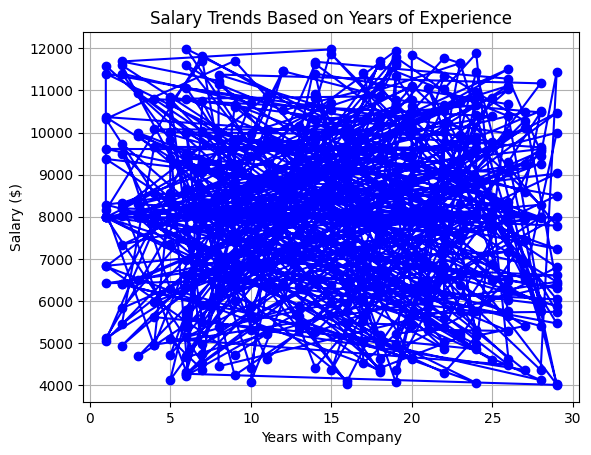

In [39]:
plt.plot(df['S_Duration'], df['Salary'], marker='o', linestyle='-', color='b')
plt.title('Salary Trends Based on Years of Experience')
plt.xlabel('Years with Company')
plt.ylabel('Salary ($)')
plt.grid(True)
plt.show()

# Pie Chart: 
### Create a pie chart to show the distribution of genders in the company. What
### insights can you draw from this distribution?

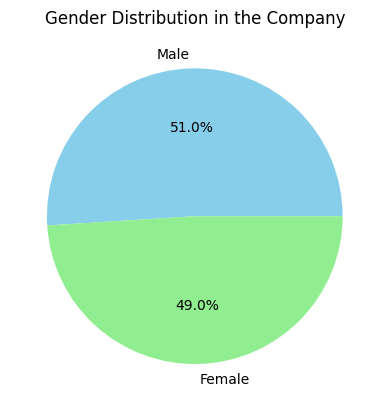

In [41]:
gender_distribution = df['Gender'].value_counts()
# Create pie chart
plt.pie(gender_distribution, labels=gender_distribution.index, autopct='%1.1f%%', colors=['skyblue', 'lightgreen'])
plt.title('Gender Distribution in the Company')
plt.show()

# Promotion Eligibility Distribution

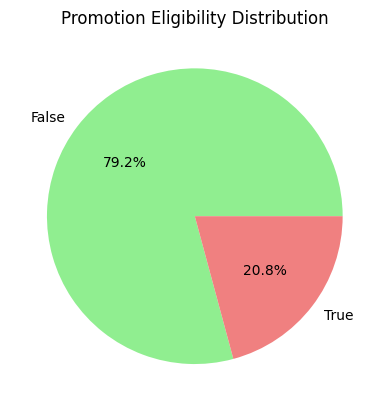

In [43]:
promotion_distribution = df['eligibility'].value_counts()

# Create pie chart
plt.pie(promotion_distribution, labels=promotion_distribution.index, autopct='%1.1f%%', colors=['lightgreen', 'lightcoral'])
plt.title('Promotion Eligibility Distribution')
plt.show()